# Cached Prediction EDA (All Genes, PLAM dynamicrank)

Streamlined analysis notebook for cached LORO outputs with all-genes model fits.

PLAM cache directory target: `plam_dynamicrank`.


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ar_utils.results_eda import *


In [2]:
import importlib
import ar_utils.results_eda
importlib.reload(ar_utils.results_eda)

<module 'ar_utils.results_eda' from '/scratch/asr655/neuroinformatics/Seq2GeneEx/gtex_gp/ar_utils/results_eda.py'>

In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    hvg_path='data/raw/ahba_100hvg.txt',
    cache_root='out/loro_subject_cache',
    gene_scope='allgenes',
    plam_cache_dirname='plam_dynamicrank'
)
CFG
print('analysis scope:', CFG.gene_scope)


analysis scope: allgenes


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


subjects: 313
genes: 13618
parcels: 150


In [5]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(10)


n (subjects in pool) = 313; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,12,LH-EXA,caudate (basal ganglia); putamen (basal ganglia),293,519,LH-EXA: caudate (basal ganglia); putamen (basa...
1,18,LH-NAC,nucleus accumbens (basal ganglia),270,270,LH-NAC: nucleus accumbens (basal ganglia)
2,5,Cerebellar_Region5,cerebellar hemisphere,261,261,Cerebellar_Region5: cerebellar hemisphere
3,0,Cerebellar_Region1,cerebellum,251,251,Cerebellar_Region1: cerebellum
4,38,LH_Default_PFC_5,frontal cortex (ba9),250,250,LH_Default_PFC_5: frontal cortex (ba9)
5,16,LH-HTH,hypothalamus,241,241,LH-HTH: hypothalamus
6,21,LH-RN,hippocampus,239,239,LH-RN: hippocampus
7,109,RH_Default_PFCdPFCm_1,cortex,237,237,RH_Default_PFCdPFCm_1: cortex
8,132,RH_SalVentAttn_Med_2,anterior cingulate cortex (ba24),220,220,RH_SalVentAttn_Med_2: anterior cingulate corte...
9,88,RH-MN,amygdala,181,181,RH-MN: amygdala


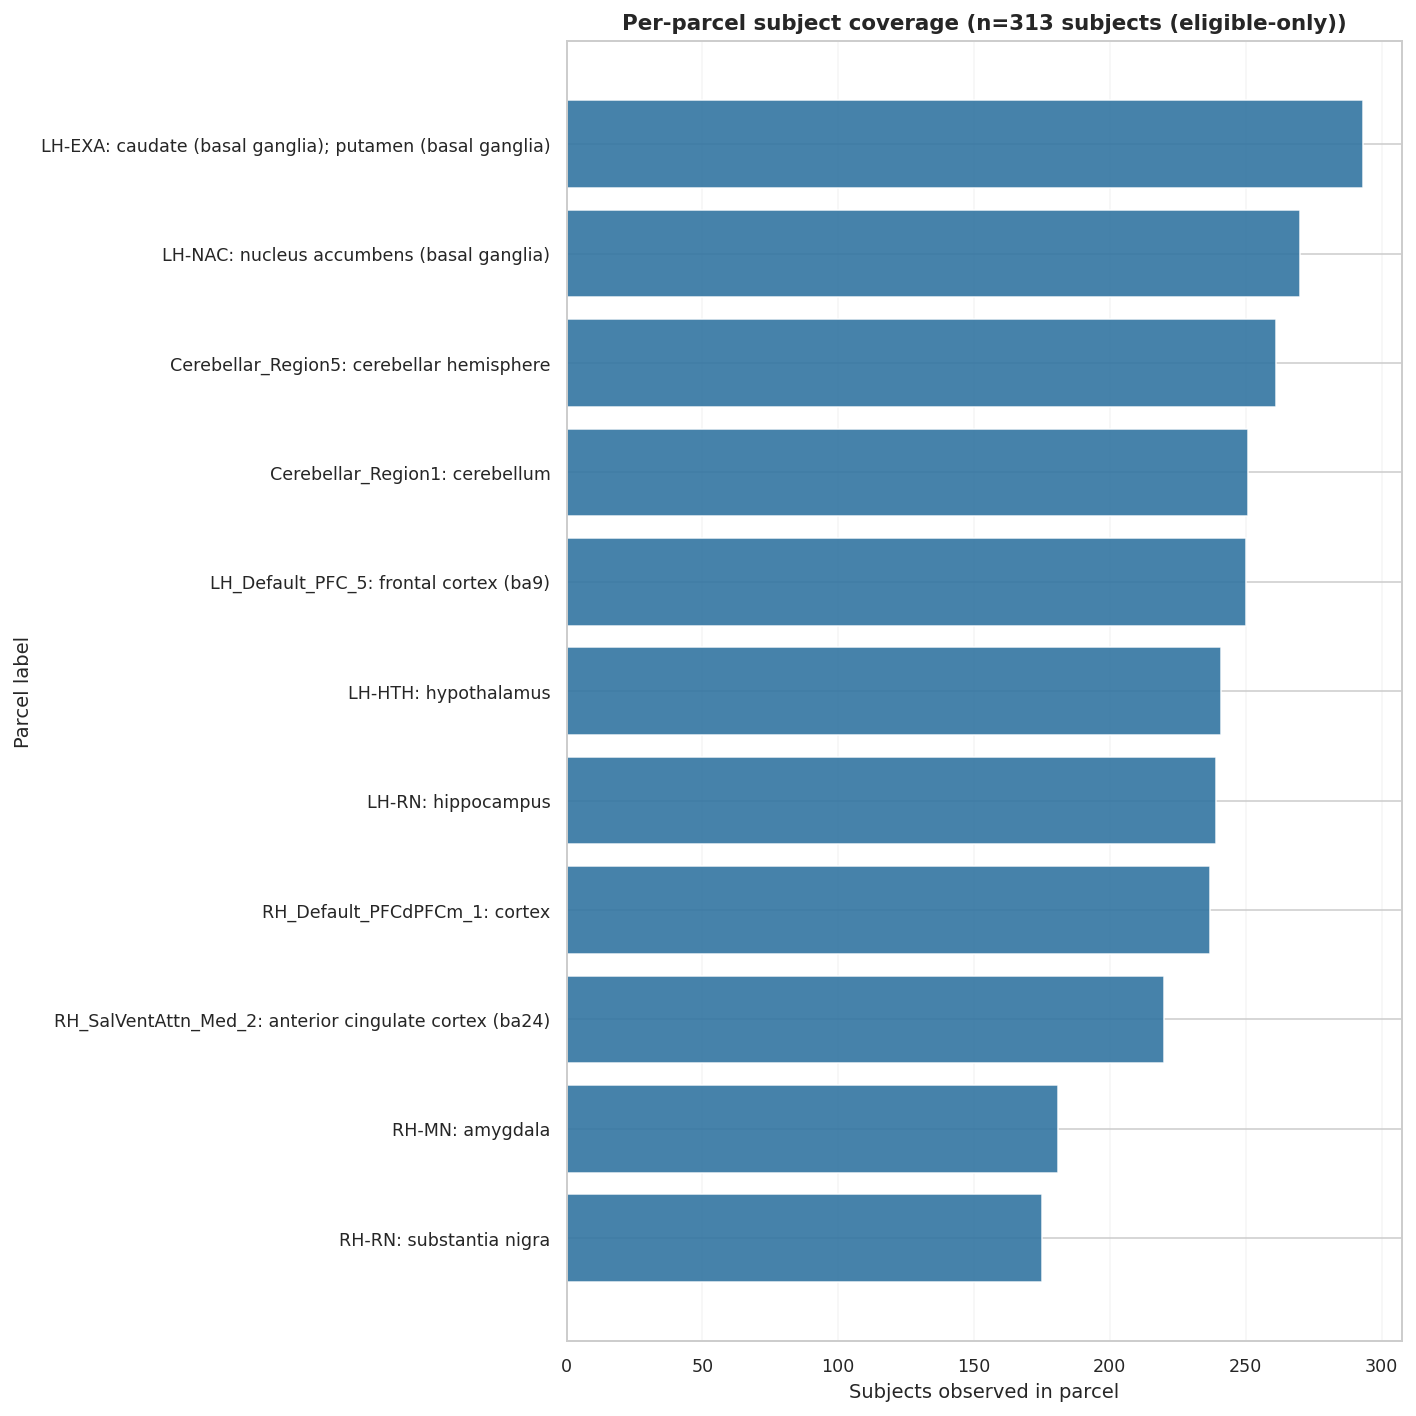

In [6]:
fig_h = max(8.0, 0.20 * len(count_df))
fig, ax = plot_parcel_subject_counts(count_df, top_n=None, min_subjects=1, figsize=(10, 10))


,n_regions_sampled,n_subjects,eligible_only,n_subjects_pool
0,5,27,True,313
1,6,34,True,313
2,7,38,True,313
3,8,53,True,313
4,9,54,True,313
5,10,74,True,313
6,11,33,True,313


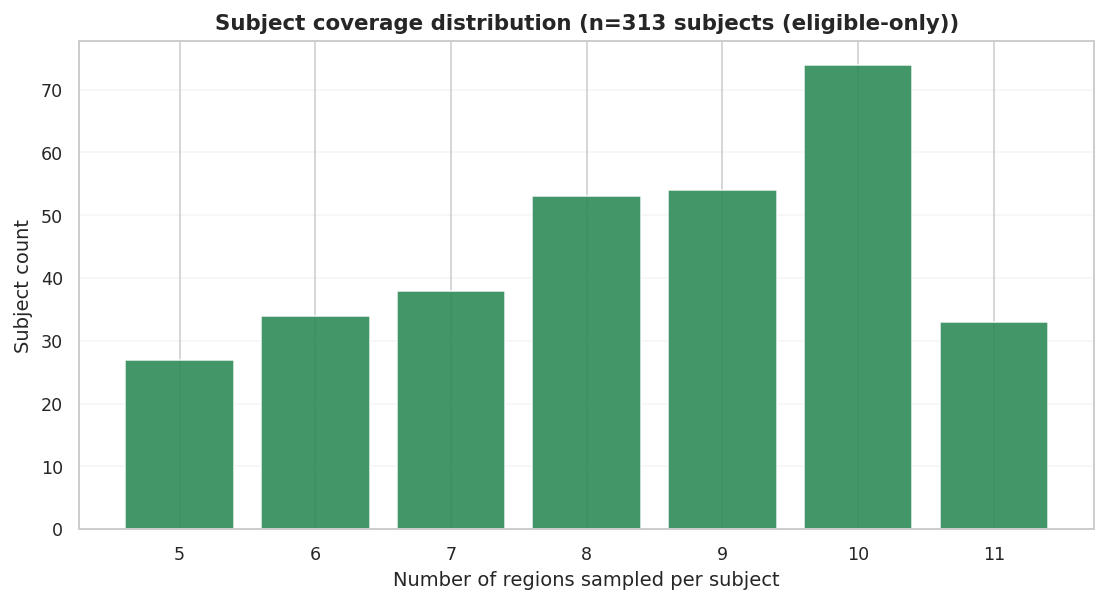

In [7]:
# LORO-relevant: x=regions sampled per subject, y=subject count
subj_cov = subject_region_count_distribution(PREPOST, eligible_only=ELIGIBLE_ONLY)
display(subj_cov)
fig, ax = plot_subject_region_count_distribution(subj_cov)


## 2) Pre/Post ComBat Diagnostics


In [8]:
# gene_mode: 'hvg' | 'allgenes' | 'custom'
GENE_MODE = 'hvg'
CUSTOM_GENE_LIST = None

atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 11
genes in panel: 88


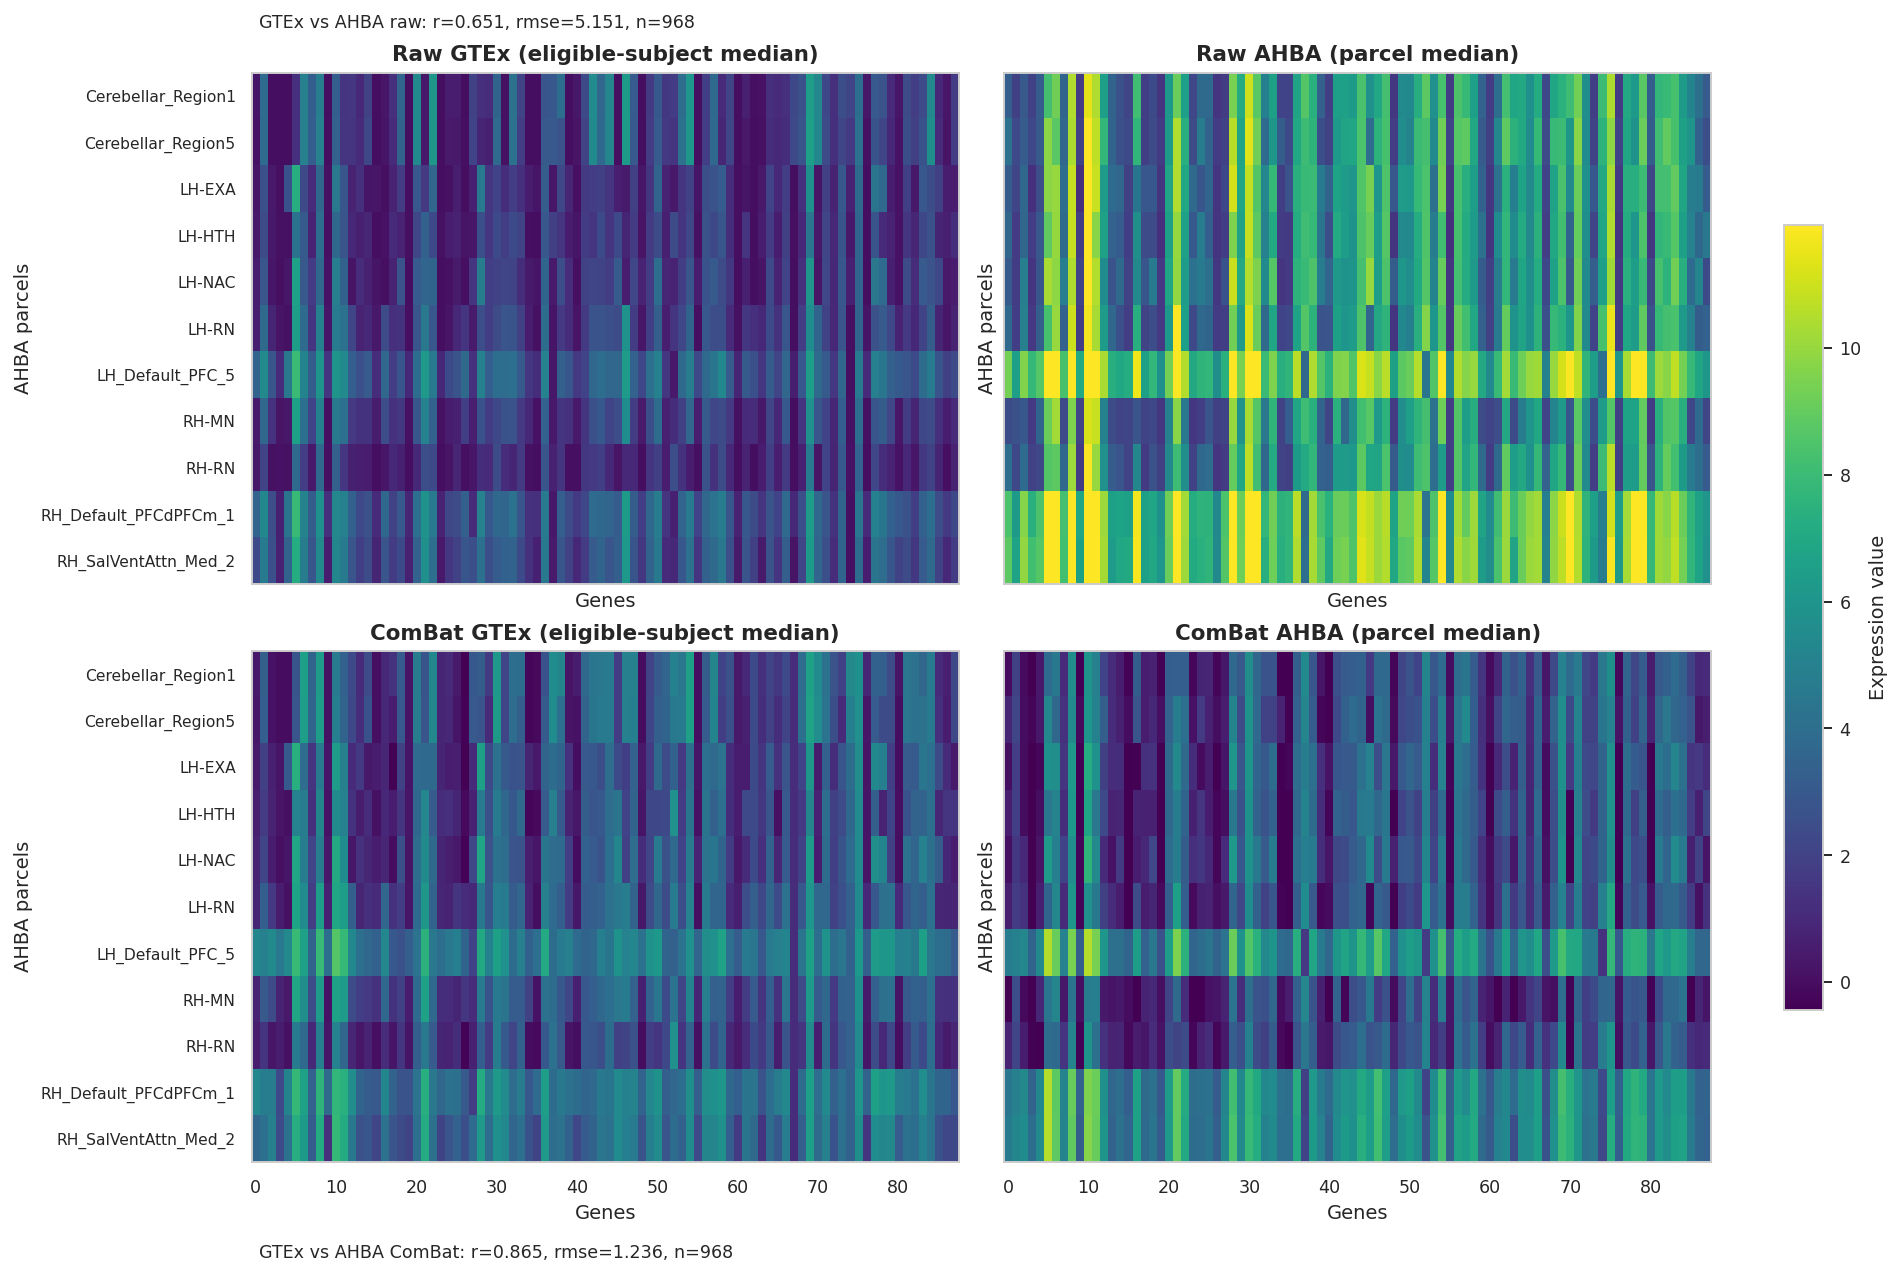

In [9]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


subject: GTEX-1117F


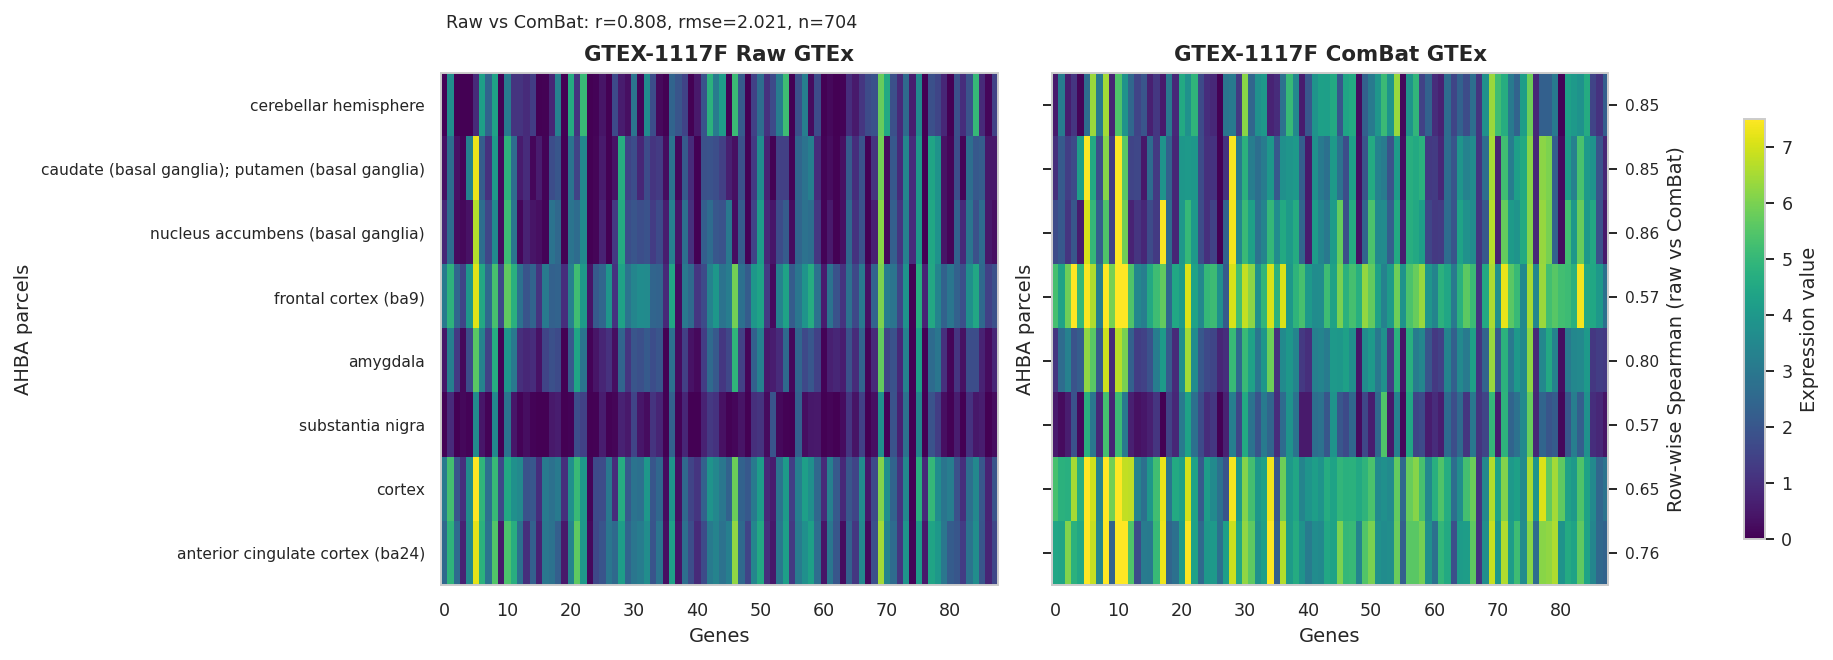

In [10]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    gene_list=CUSTOM_GENE_LIST,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


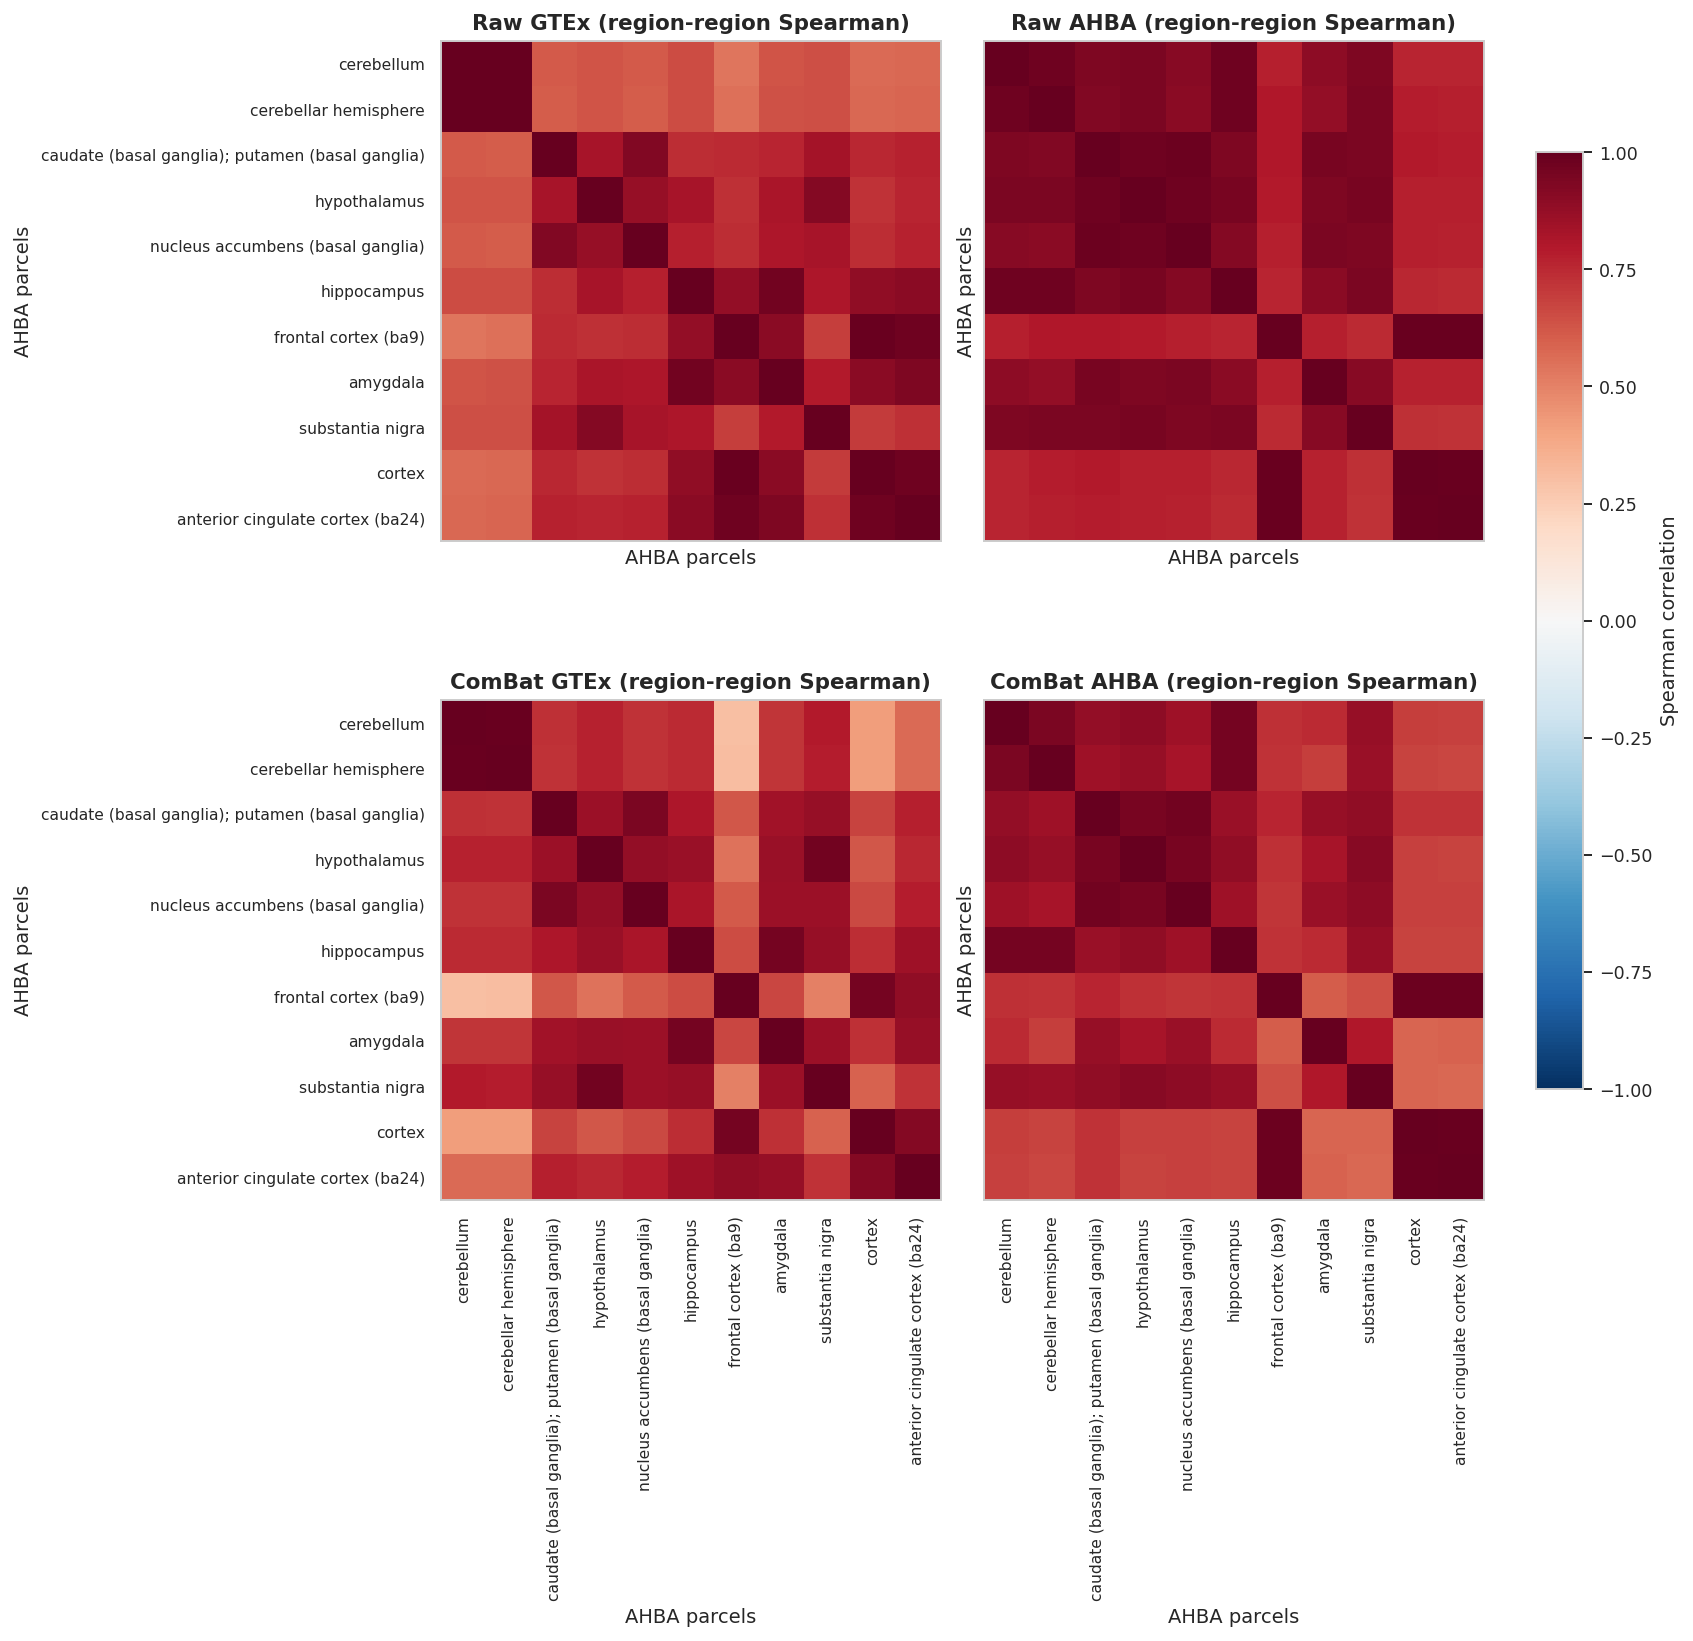

In [11]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


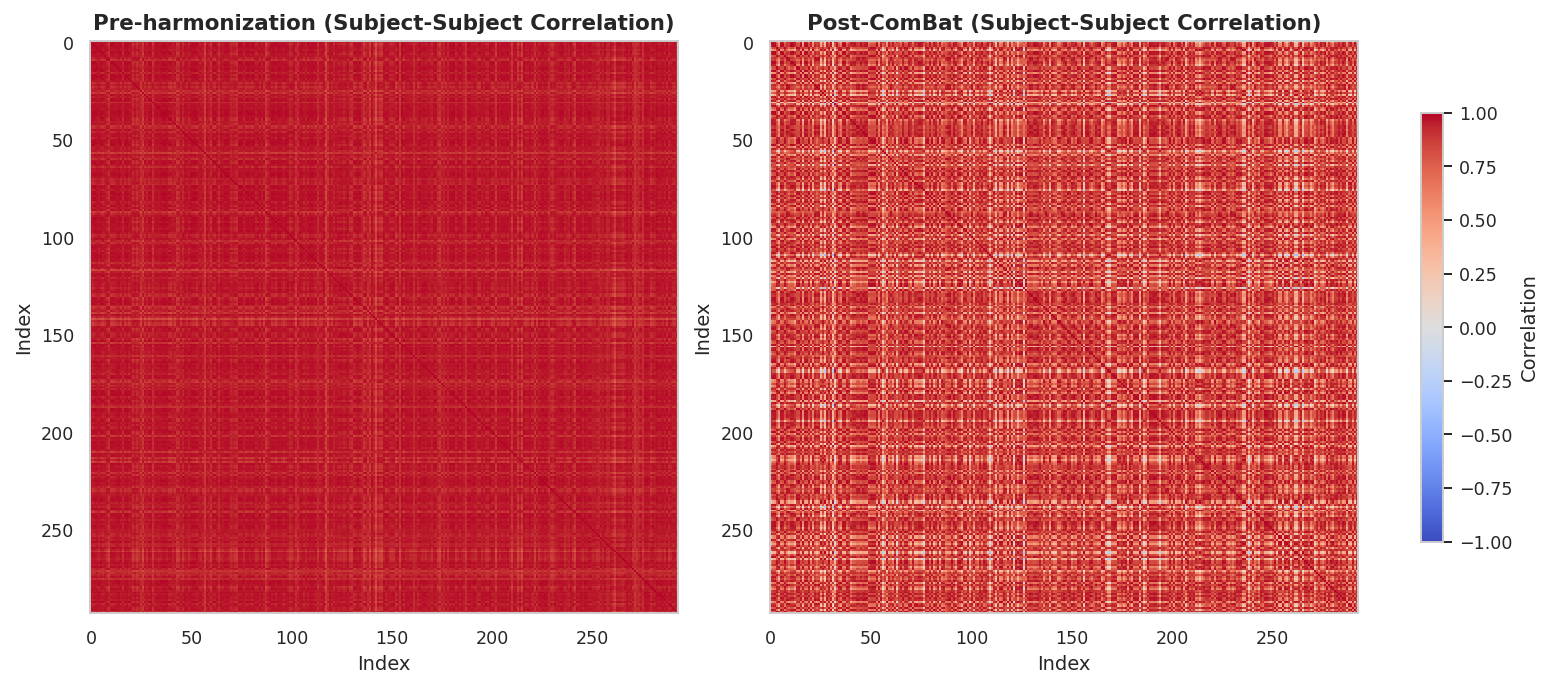

In [12]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')


## 3) Coverage vs Accuracy


In [13]:
# allgenes-fit cache metrics, evaluated on all genes
naive_all = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_mode='all')
dlam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_mode='all')
plam_all  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_mode='all')
metrics_allgenes_eval = pd.concat([naive_all, dlam_all, plam_all], ignore_index=True)

# allgenes-fit cache metrics, evaluated on HVG subset
naive_hvg = compute_subject_metrics_from_cache_gene_subset(CFG, model='naive', eval_gene_mode='hvg')
dlam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='dlam',  eval_gene_mode='hvg')
plam_hvg  = compute_subject_metrics_from_cache_gene_subset(CFG, model='plam',  eval_gene_mode='hvg')
metrics_hvg_eval_on_allgenes_fit = pd.concat([naive_hvg, dlam_hvg, plam_hvg], ignore_index=True)

display(metrics_allgenes_eval.head())
display(metrics_hvg_eval_on_allgenes_fit.head())


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,n_points,pearson_r,rmse
0,GTEX-11ZU8,naive,5,5,13618,13618,all,68090,0.675178,1.647290
1,GTEX-131XW,naive,5,5,13618,13618,all,68090,0.741732,1.424494
2,GTEX-13CZV,naive,5,5,13618,13618,all,68090,0.697778,1.453321
3,GTEX-13NZA,naive,5,5,13618,13618,all,68090,0.712056,1.589837
4,GTEX-145MG,naive,5,5,13618,13618,all,68090,0.706701,1.434562


,subject,model,coverage,n_loro_parcels,n_eval_genes,n_total_genes,eval_gene_mode,n_points,pearson_r,rmse
0,GTEX-11ZU8,naive,5,5,88,13618,hvg,440,0.866813,1.552024
1,GTEX-131XW,naive,5,5,88,13618,hvg,440,0.833423,1.882198
2,GTEX-13CZV,naive,5,5,88,13618,hvg,440,0.852467,1.456364
3,GTEX-13NZA,naive,5,5,88,13618,hvg,440,0.824057,1.671875
4,GTEX-145MG,naive,5,5,88,13618,hvg,440,0.814112,1.665782


In [14]:
import importlib
import ar_utils.results_eda
importlib.reload(ar_utils.results_eda)
from ar_utils.results_eda import *

,model,pearson_mean,pearson_std,rmse_mean,rmse_std,n_subjects,pearson_err,rmse_err
0,naive,0.723632,0.027060,1.387230,0.103200,313,0.027060,0.103200
1,dlam,0.876083,0.098725,0.998095,0.614648,313,0.098725,0.614648
2,plam,0.830996,0.077321,1.077493,0.363076,313,0.077321,0.363076


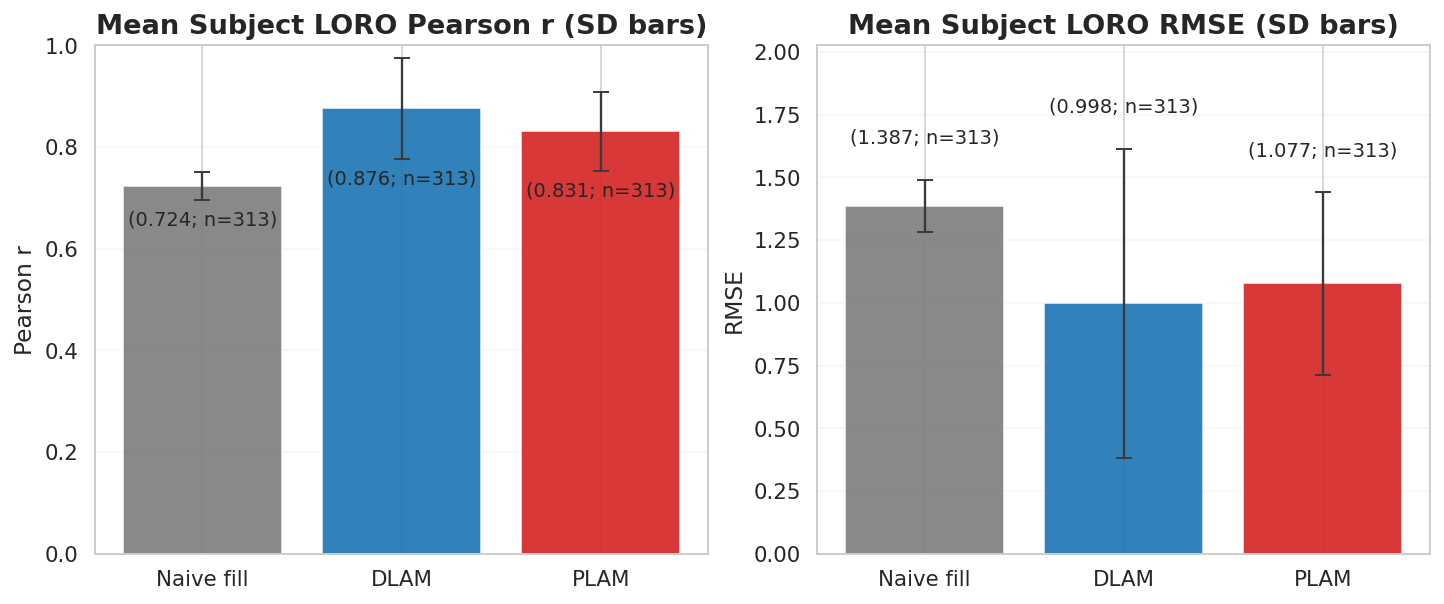

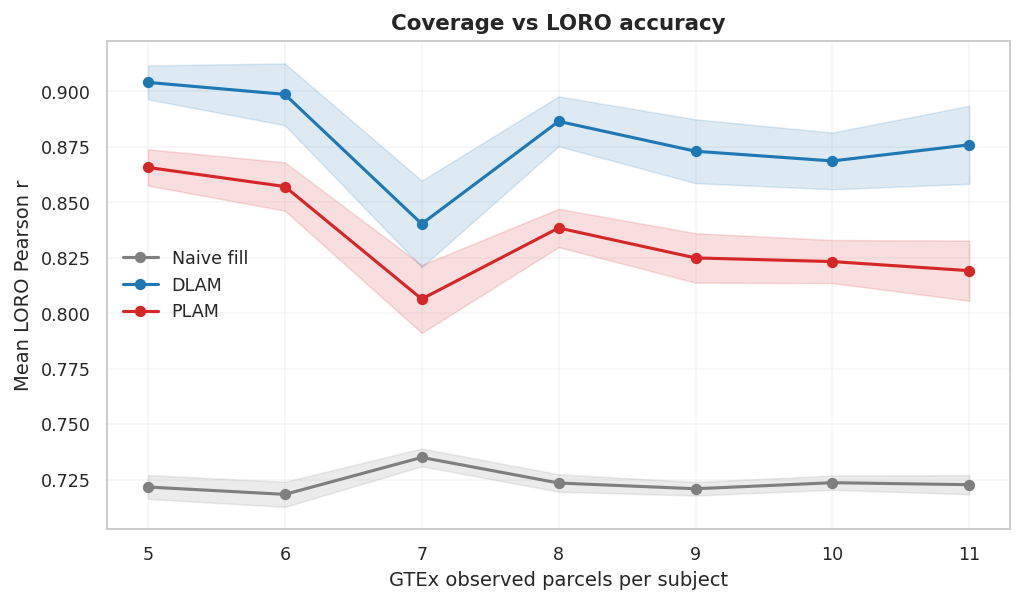

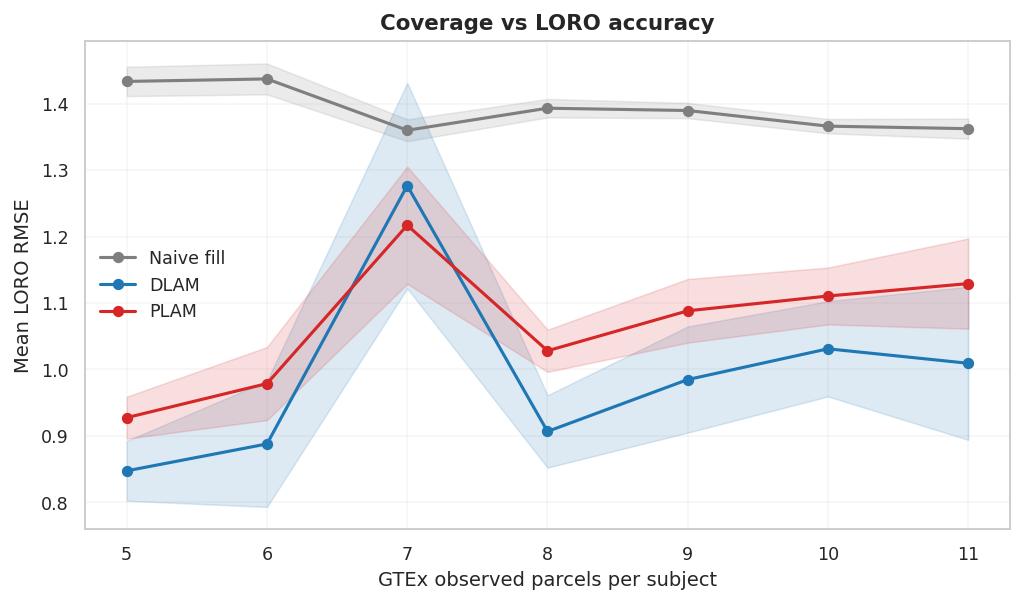

In [15]:
fig, axes, summary_all = plot_loro_subject_summary_bars(metrics_allgenes_eval, use_sem=False)
display(summary_all)
fig, ax = plot_coverage_vs_accuracy(metrics_allgenes_eval, metric='pearson_r')
fig, ax = plot_coverage_vs_accuracy(metrics_allgenes_eval, metric='rmse')


,model,pearson_mean,pearson_std,rmse_mean,rmse_std,n_subjects,pearson_err,rmse_err
0,naive,0.811316,0.039957,1.485770,0.219263,313,0.039957,0.219263
1,dlam,0.712077,0.117338,1.707058,0.543972,313,0.117338,0.543972
2,plam,0.781811,0.055339,1.493370,0.302911,313,0.055339,0.302911


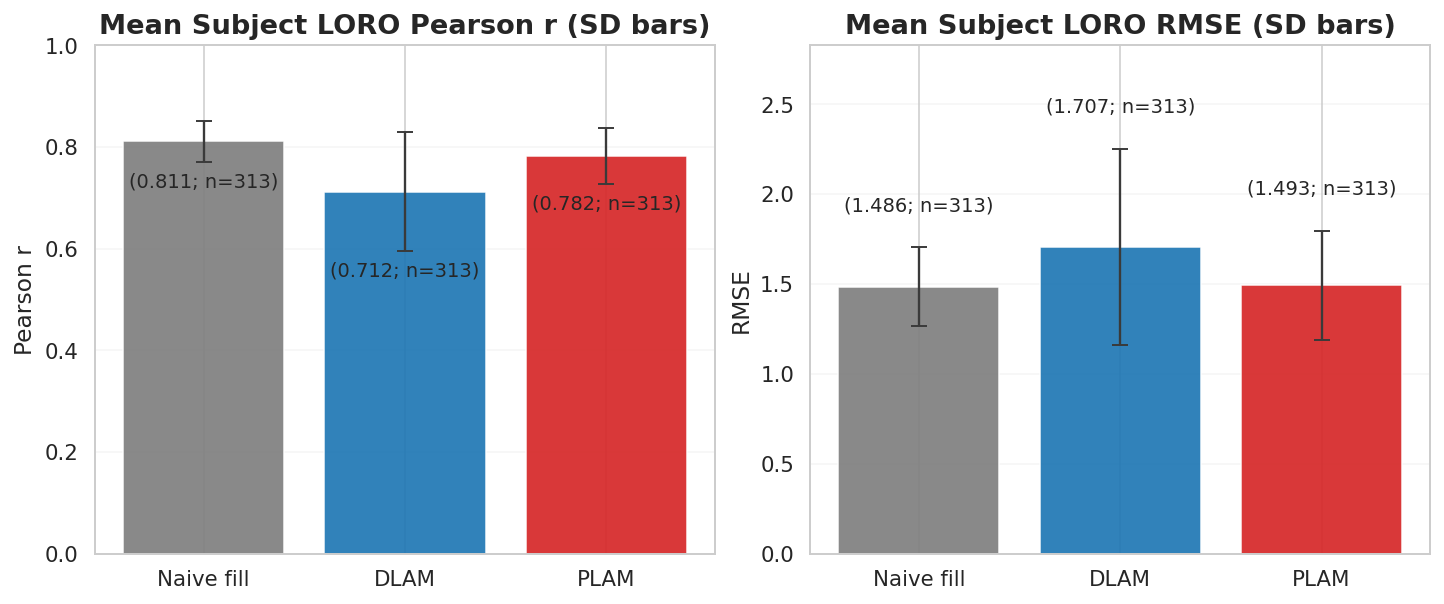

In [16]:
fig, axes, summary_hvg = plot_loro_subject_summary_bars(metrics_hvg_eval_on_allgenes_fit, use_sem=False)
display(summary_hvg)


## 4) Fold-Combo Difficulty


In [17]:
fold_perf_df, combo_df = compute_fold_combo_metrics_from_cache(
    CFG, PREPOST,
    eval_gene_mode='all',
    custom_gene_list=None,
    coverage_min=5,
    coverage_max=11,
    models=['naive', 'dlam', 'plam'],
)
print('fold_perf_df:', fold_perf_df.shape)
print('combo_df:', combo_df.shape)
display(combo_df.head())


fold_perf_df: (7854, 10)
combo_df: (3618, 10)


,coverage,fold_key,model,n_subjects,mean_pearson,std_pearson,mean_rmse,std_rmse,mean_points,eval_gene_mode
0,5,"hold=0|train=12,16,109,132",dlam,1,0.784850,NaN,1.118982,NaN,13618.0,all
1,5,"hold=0|train=12,16,38,109",dlam,1,0.904678,NaN,0.938706,NaN,13618.0,all
2,5,"hold=0|train=12,16,93,109",dlam,1,0.896133,NaN,0.819912,NaN,13618.0,all
3,5,"hold=0|train=12,38,109,132",dlam,1,0.906370,NaN,1.005627,NaN,13618.0,all
4,5,"hold=0|train=21,38,93,109",dlam,1,0.891065,NaN,0.830649,NaN,13618.0,all


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,naive,mean_pearson,0.585803,7,1,"hold=38|train=12,16,18,21,93,132",38,frontal cortex (ba9),"[12, 16, 18, 21, 93, 132]",[caudate (basal ganglia); putamen (basal gangl...
1,median,naive,mean_pearson,0.741124,6,1,"hold=12|train=5,18,38,109,132",12,caudate (basal ganglia); putamen (basal ganglia),"[5, 18, 38, 109, 132]","[cerebellar hemisphere, nucleus accumbens (bas..."
2,best,naive,mean_pearson,0.823113,10,1,"hold=16|train=0,5,12,21,38,88,93,109,132",16,hypothalamus,"[0, 5, 12, 21, 38, 88, 93, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,dlam,mean_pearson,0.361104,8,1,"hold=88|train=0,5,12,16,18,109,132",88,amygdala,"[0, 5, 12, 16, 18, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
1,median,dlam,mean_pearson,0.898694,8,2,"hold=132|train=0,5,12,16,18,21,38",132,anterior cingulate cortex (ba24),"[0, 5, 12, 16, 18, 21, 38]","[cerebellum, cerebellar hemisphere, caudate (b..."
2,best,dlam,mean_pearson,0.984160,6,1,"hold=18|train=12,38,88,109,132",18,nucleus accumbens (basal ganglia),"[12, 38, 88, 109, 132]",[caudate (basal ganglia); putamen (basal gangl...


,rank_tag,model,metric,score,coverage,n_subjects,fold_key,hold_parcel,hold_gtex,train_parcels,train_gtex
0,worst,plam,mean_pearson,0.517072,8,1,"hold=88|train=0,5,12,16,18,109,132",88,amygdala,"[0, 5, 12, 16, 18, 109, 132]","[cerebellum, cerebellar hemisphere, caudate (b..."
1,median,plam,mean_pearson,0.863007,5,1,"hold=109|train=0,5,16,93",109,cortex,"[0, 5, 16, 93]","[cerebellum, cerebellar hemisphere, hypothalam..."
2,best,plam,mean_pearson,0.963404,6,1,"hold=12|train=0,16,18,21,109",12,caudate (basal ganglia); putamen (basal ganglia),"[0, 16, 18, 21, 109]","[cerebellum, hypothalamus, nucleus accumbens (..."


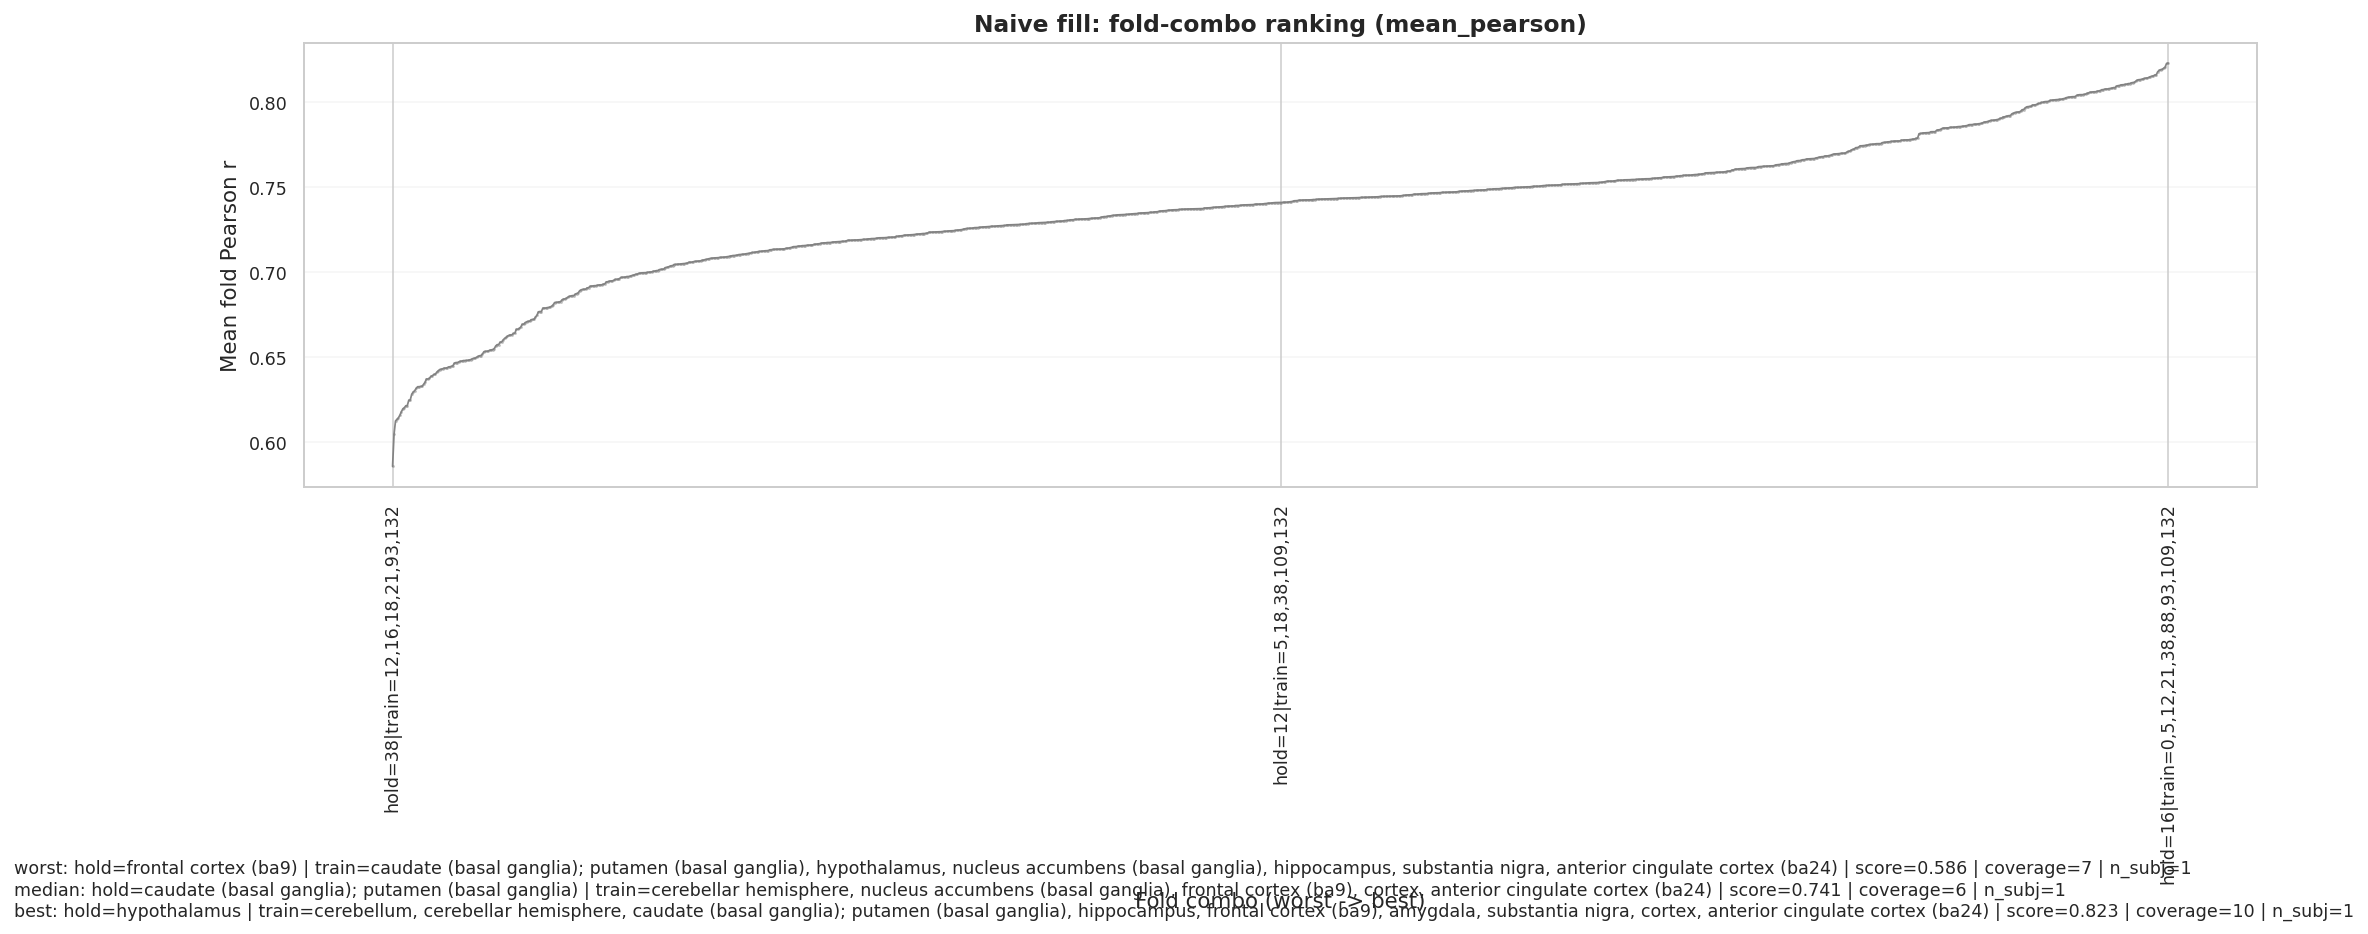

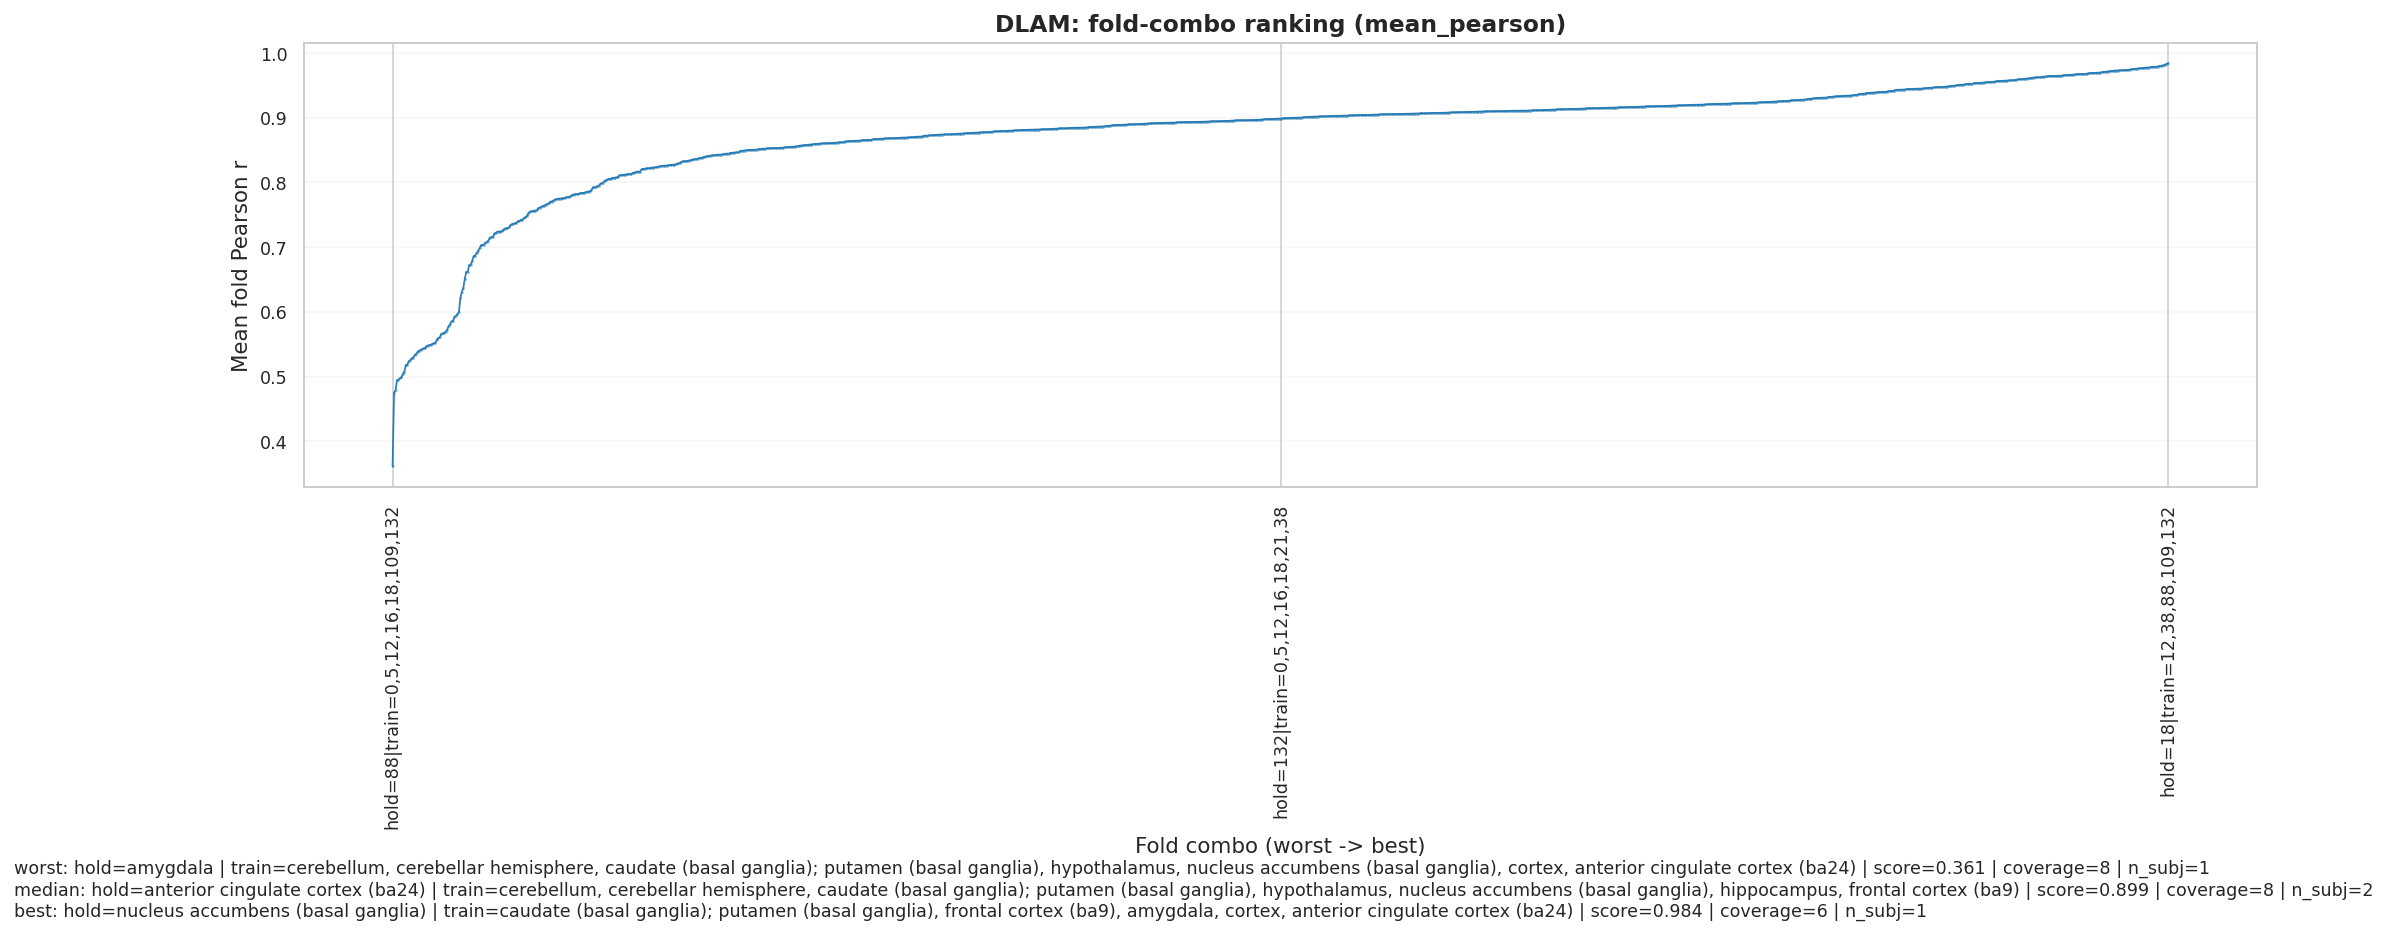

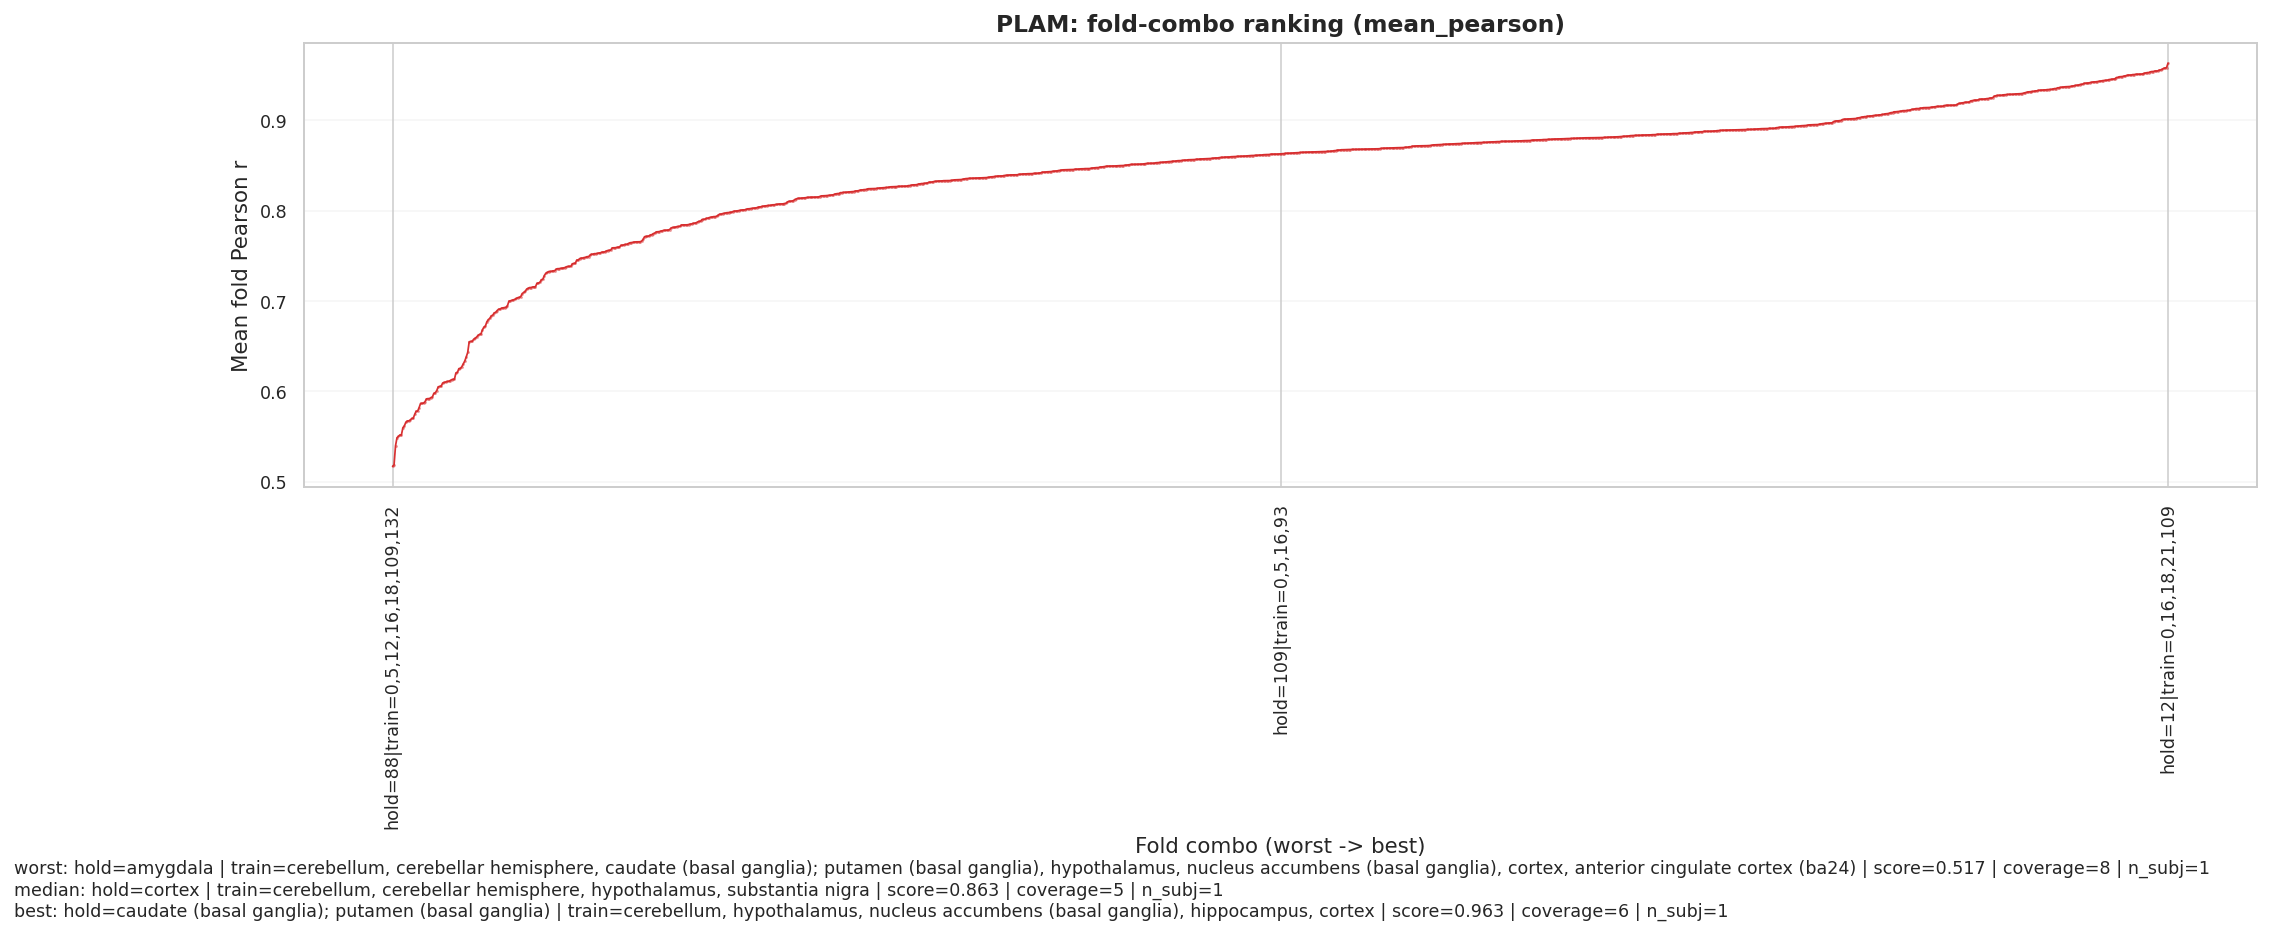

In [18]:
for model_name in ['naive', 'dlam', 'plam']:
    fig, ax, key_table = plot_fold_combo_ranked(combo_df, PREPOST, model=model_name, metric='mean_pearson')
    display(key_table)


,hold_parcel,model,n_subjects,n_folds,mean_pearson,std_pearson,mean_rmse,std_rmse,gtex_label,ahba_label,label
0,0,dlam,251,251,0.887645,0.096795,0.971644,0.659322,cerebellum,Cerebellar_Region1,cerebellum
1,0,naive,251,251,0.759283,0.025393,1.289612,0.097651,cerebellum,Cerebellar_Region1,cerebellum
2,0,plam,251,251,0.863493,0.082536,1.016232,0.483096,cerebellum,Cerebellar_Region1,cerebellum
3,5,dlam,261,261,0.880474,0.106908,0.983054,0.658201,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
4,5,naive,261,261,0.765969,0.026122,1.233572,0.106519,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
5,5,plam,261,261,0.854465,0.089997,1.038259,0.465458,cerebellar hemisphere,Cerebellar_Region5,cerebellar hemisphere
6,12,dlam,293,293,0.887051,0.101901,0.952599,0.617908,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
7,12,naive,293,293,0.749015,0.032174,1.421056,0.143254,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
8,12,plam,293,293,0.868083,0.080616,0.975201,0.383293,caudate (basal ganglia); putamen (basal ganglia),LH-EXA,caudate (basal ganglia); putamen (basal ganglia)
9,16,dlam,241,241,0.880191,0.097796,0.974008,0.577174,hypothalamus,LH-HTH,hypothalamus


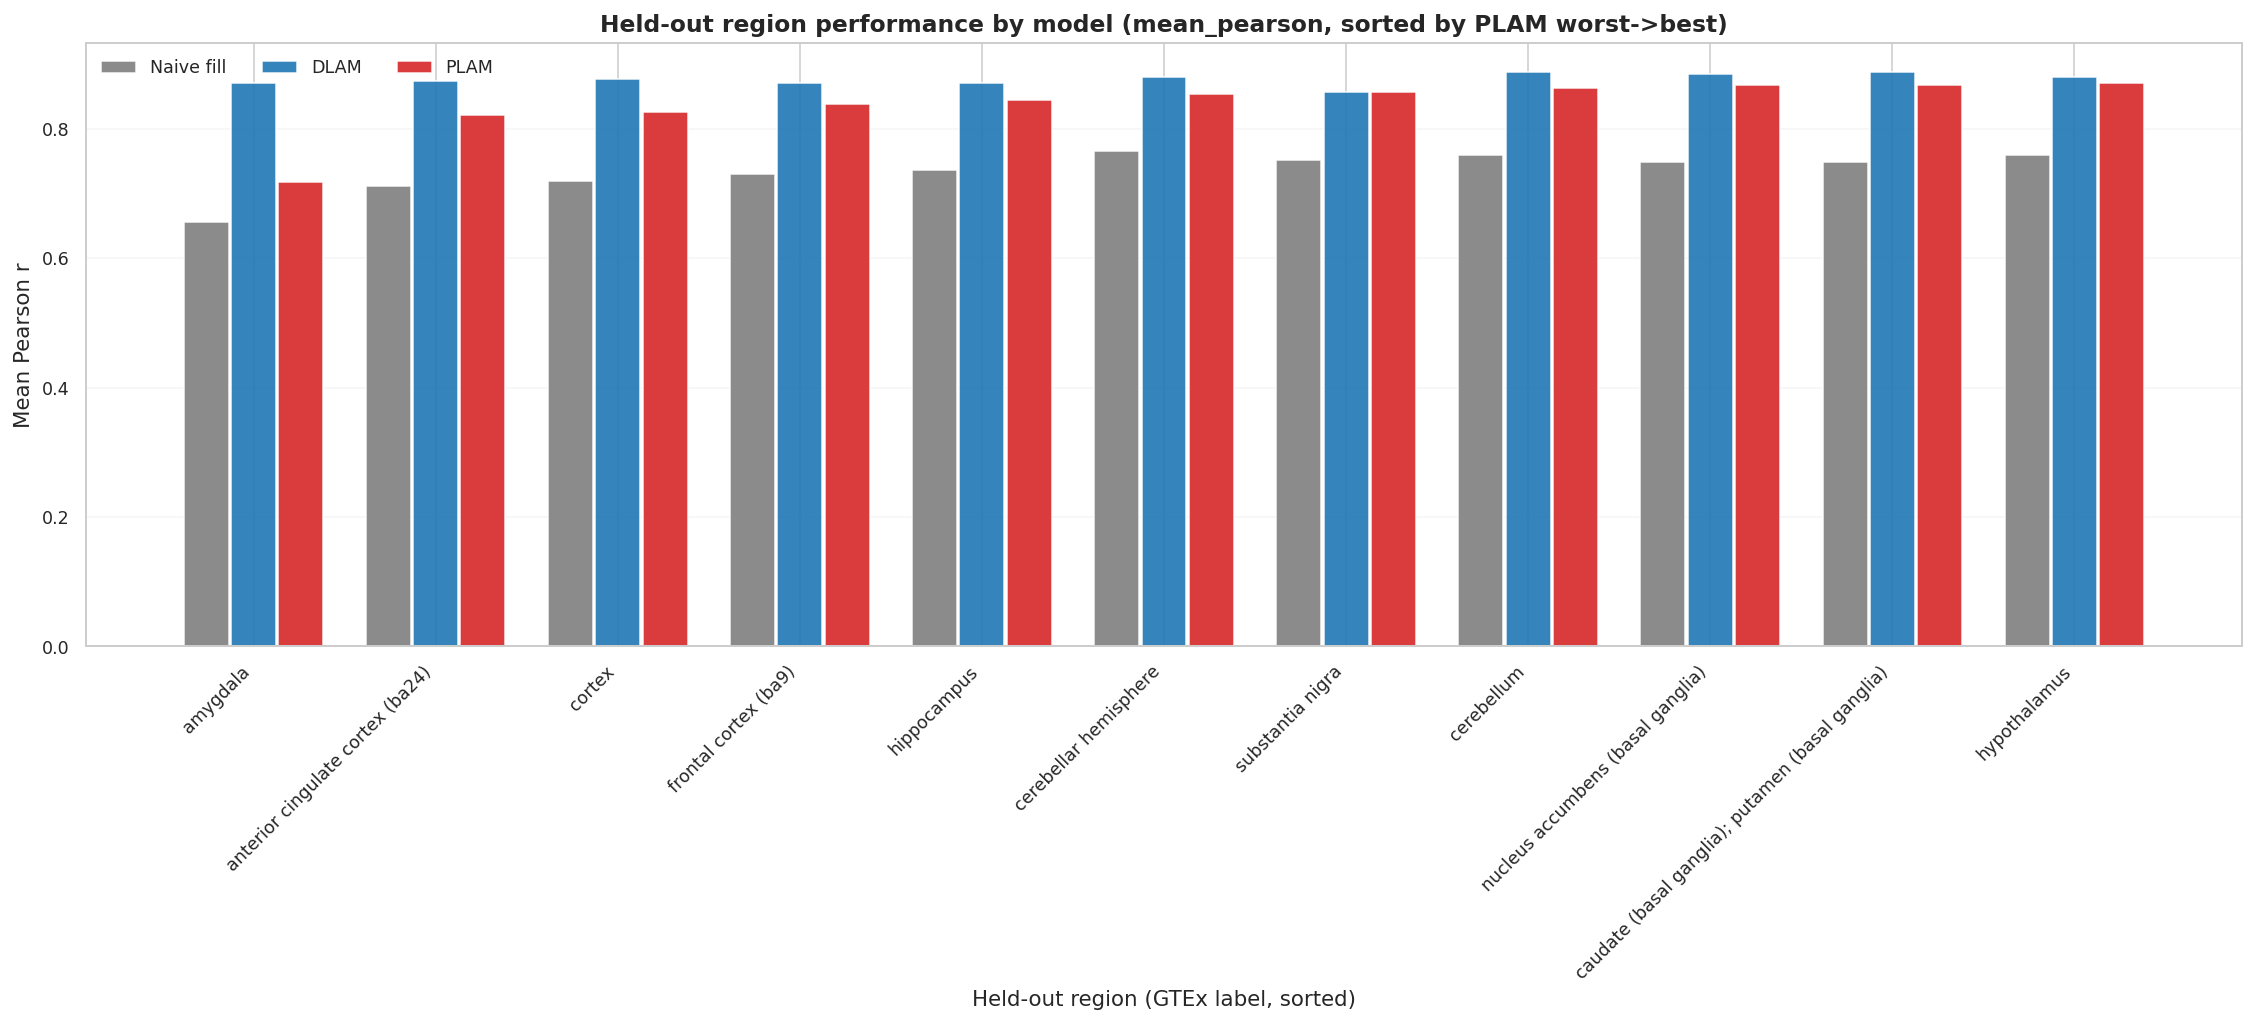

In [19]:
heldout_df = summarize_heldout_region_performance(fold_perf_df, PREPOST)
fig, ax, heldout_plot_df = plot_heldout_region_grouped_bars(
    heldout_df,
    metric='mean_pearson',
    sort_by_model='plam',
    use_error_bars=False,
    error_kind='std',
)
display(heldout_df.head(20))


## 5) Single-Subject Scatter Triplets


subject: GTEX-ZVT3


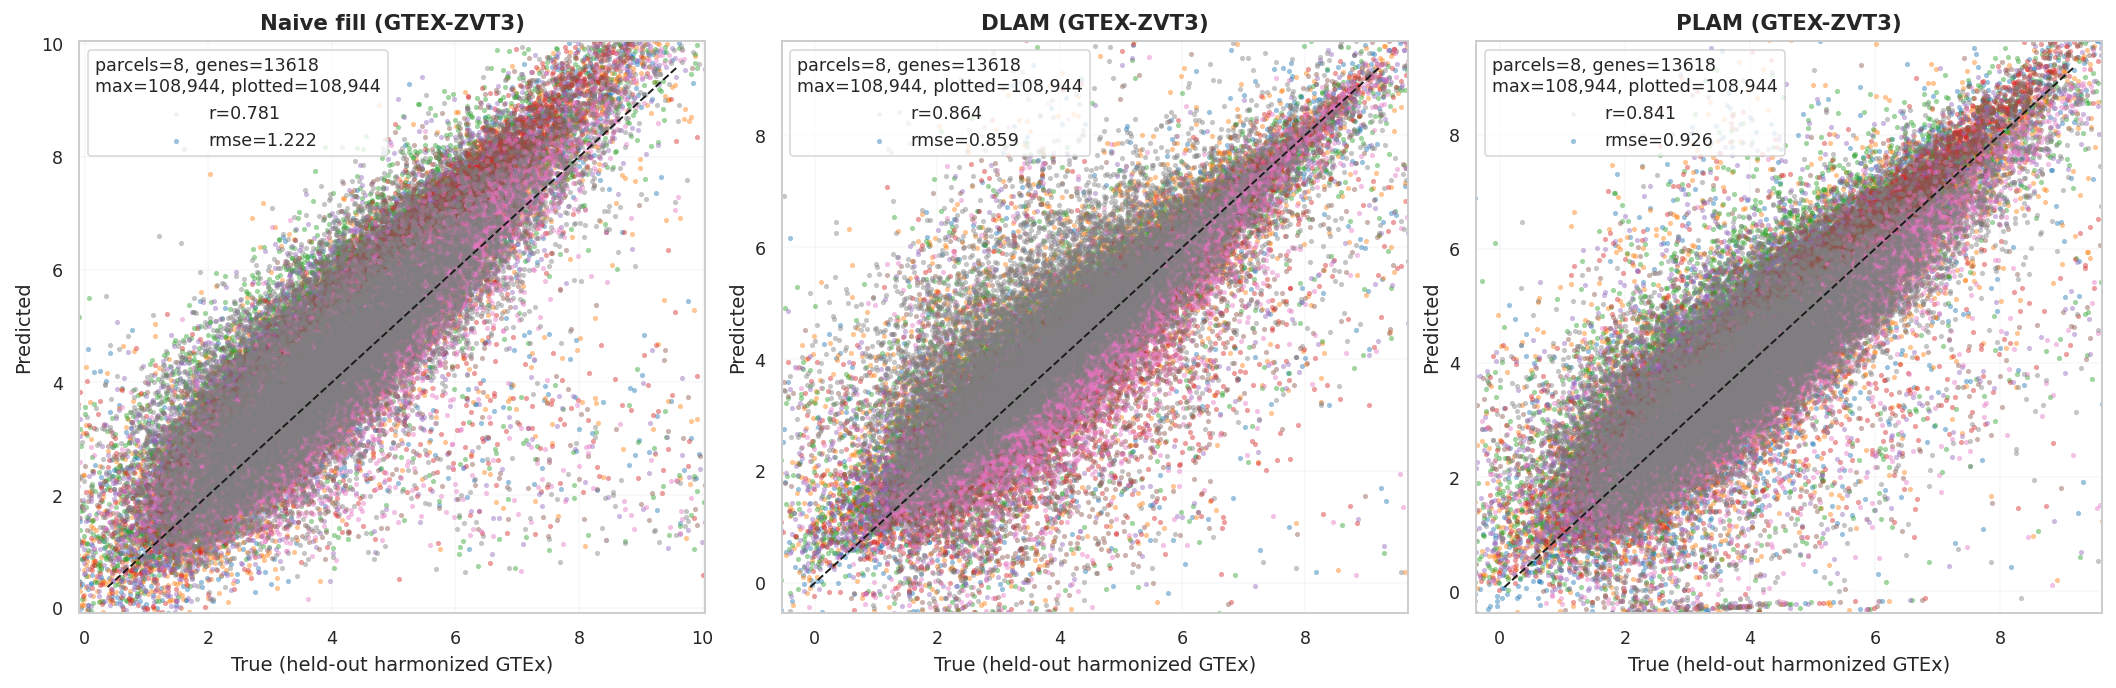

In [20]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='parcel',
    top_n=10,
)
print('subject:', subject)


subject: GTEX-ZVT3


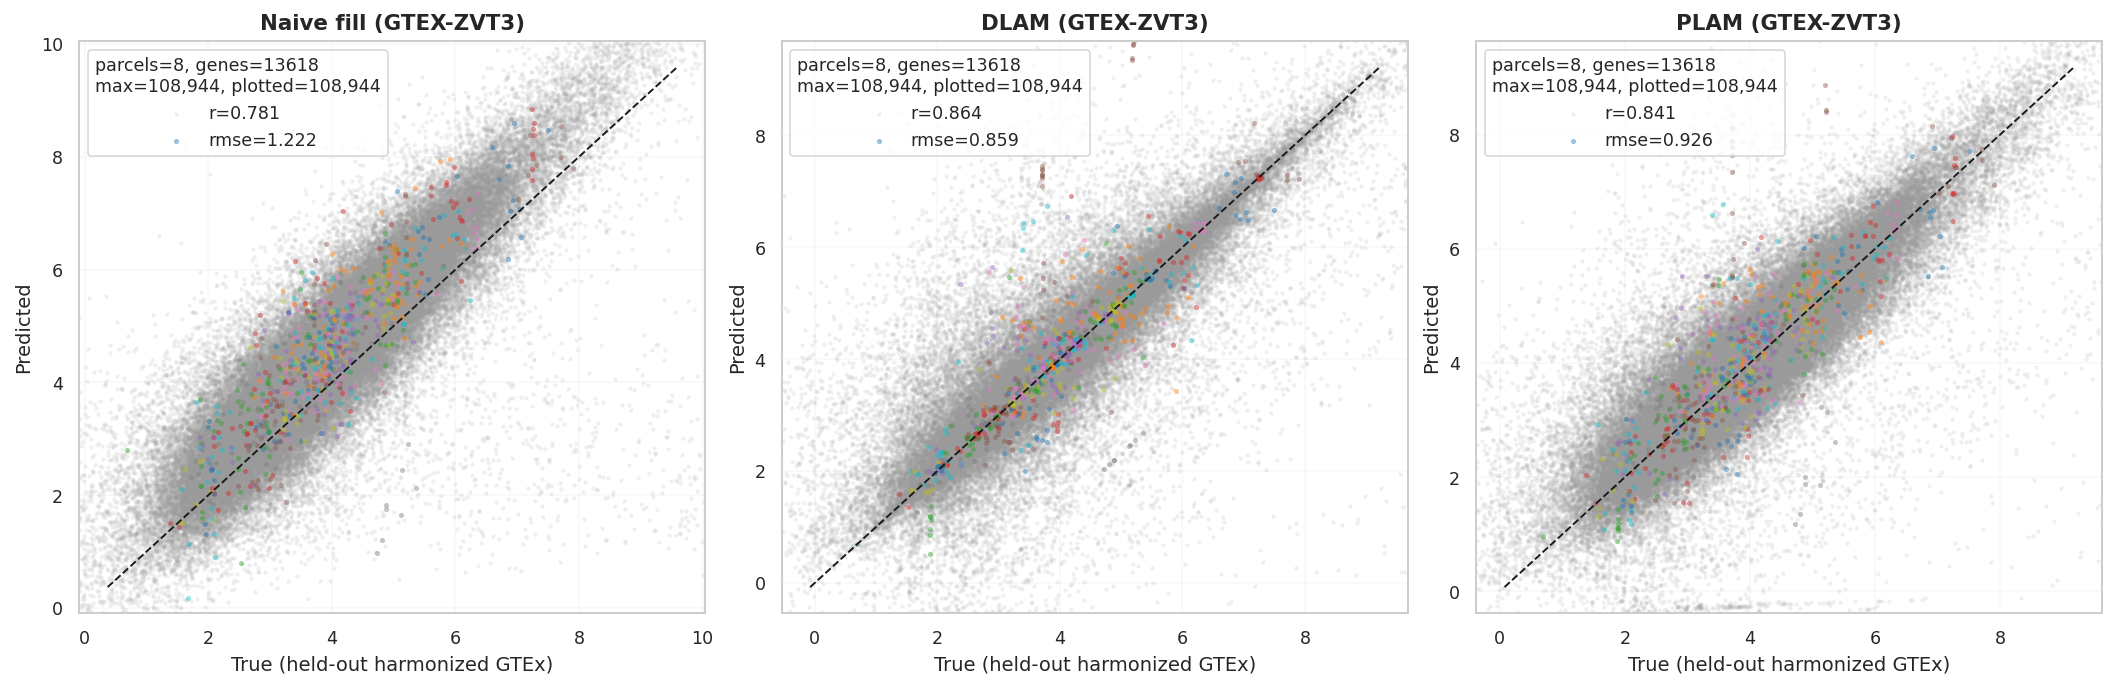

In [21]:
fig, axes, subject = plot_single_subject_scatter_triplet(
    CFG,
    subject_mode='median',
    color_by='gene',
    top_n=100,
)
print('subject:', subject)
